<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Lab%207/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

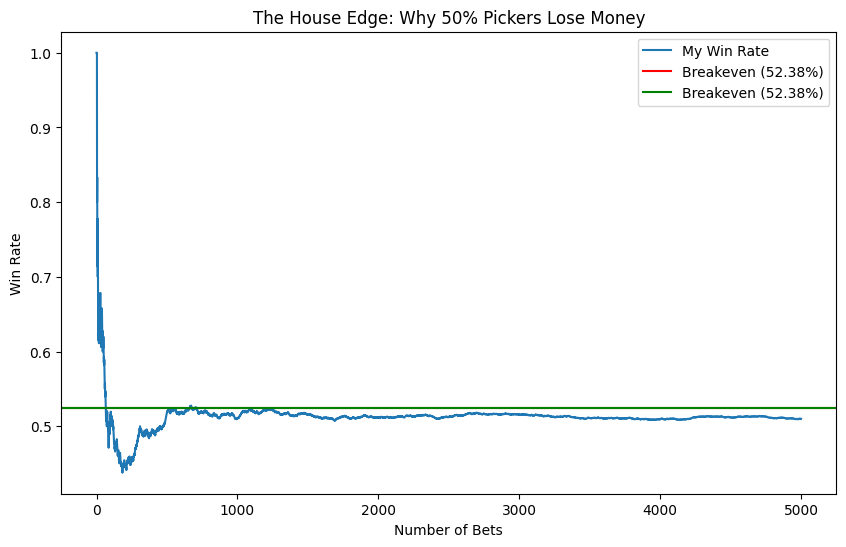

In [1]:
import numpy as np
import matplotlib.pyplot as plt

true_skill = 0.5
breakeven = 0.5238
n_bets = 5000

outcomes = np.random.choice([0,1],size = n_bets, p = [1-true_skill, true_skill])
cumulative_win_rate = np.cumsum(outcomes)/(np.arange(1, n_bets+1))

plt.figure(figsize=(10, 6))
plt.plot(cumulative_win_rate, label="My Win Rate")
plt.axhline(breakeven, color='red', label="Breakeven (52.38%)")
plt.axhline(breakeven, color='green', label="Breakeven (52.38%)")
plt.legend()
plt.title("The House Edge: Why 50% Pickers Lose Money")
plt.xlabel("Number of Bets")
plt.ylabel("Win Rate")
plt.show()

Sampling Error Audit:
sample1: Mean = 42.50% | Error = +7.23%
sample2: Mean = 49.32% | Error = +14.05%
sample3: Mean = 29.72% | Error = -5.55%


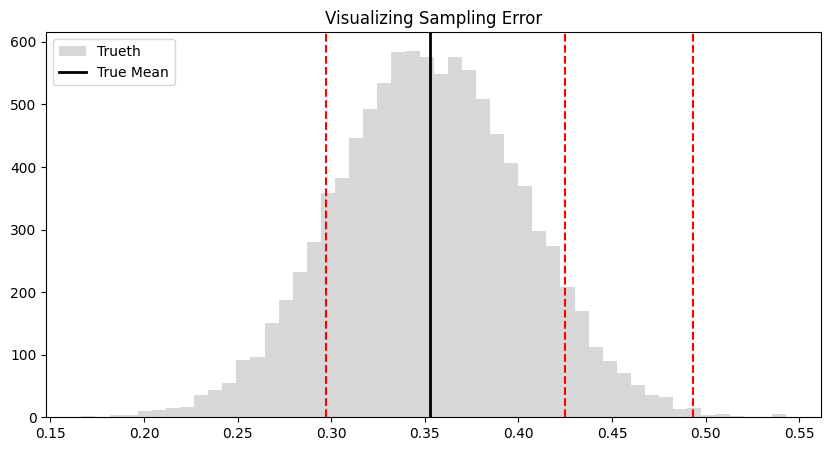

In [2]:
true_mu =0.3527

samples =[]
print(f"Sampling Error Audit:")

for i in range(3):
  sample = np.random.normal(loc=true_mu, scale=0.5, size=30)
  x_bar = sample.mean()
  error = x_bar - true_mu

  print(f"sample{i+1}: Mean = {x_bar:.2%} | Error = {error:+.2%}")
  samples.append(x_bar)

plt.figure(figsize=(10, 5))
plt.hist(np.random.normal(true_mu, 0.05, 10000), bins=50, alpha=0.3, color='gray', label='Trueth')
for mean in samples:
  plt.axvline(mean, color='red', linestyle='--')
plt.axvline(true_mu, color='black', linewidth=2, label='True Mean')
plt.title("Visualizing Sampling Error")
plt.legend()
plt.show()


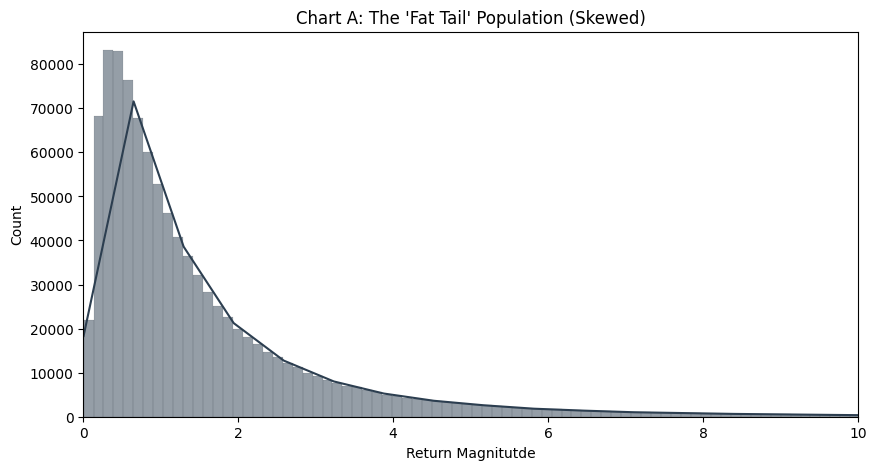

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

population_data =np.random.lognormal(mean=0, sigma=1, size=1000000)
plt.figure(figsize=(10, 5))
sns.histplot(population_data, bins=1000, kde=True, color='#2c3e50')
plt.xlim(0,10)
plt.title("Chart A: The 'Fat Tail' Population (Skewed)")
plt.xlabel("Return Magnitutde")
plt.show()

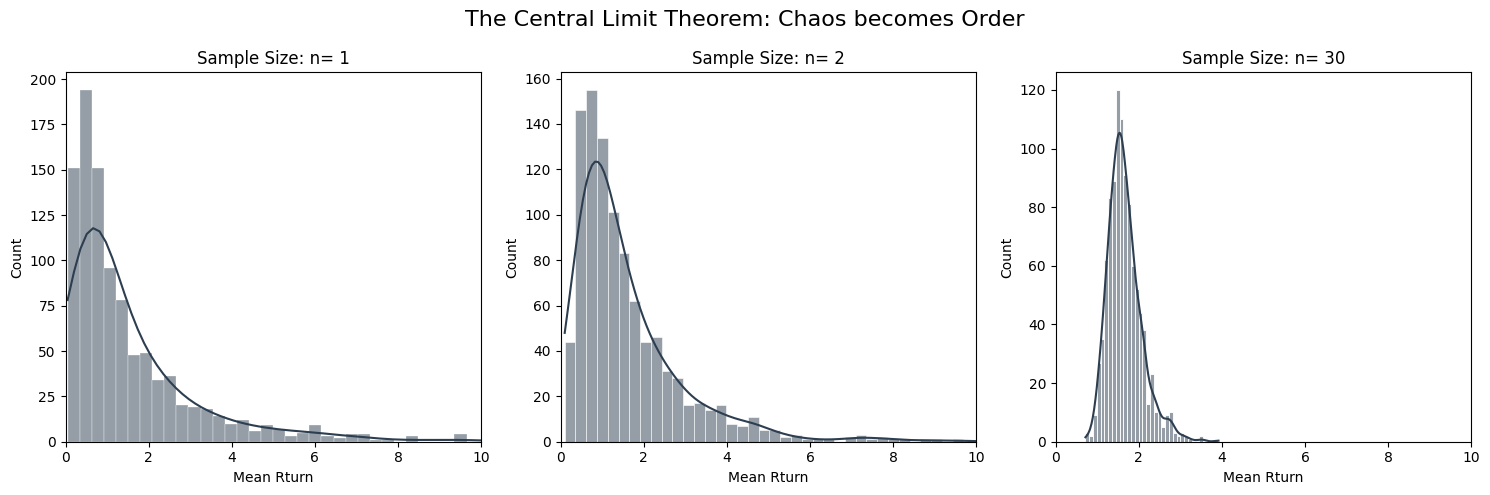

In [4]:
sample_sizes = [1,2,30]
simulations = 1000

plt.figure(figsize=(15,5))

for i, n in enumerate(sample_sizes):
  means = []
  for _ in range(simulations):
    sample = np.random.choice(population_data, size=n)
    means.append(np.mean(sample))

  plt.subplot(1,3, i+1)
  sns.histplot(means, kde=True,color='#2c3e50', edgecolor='White')
  plt.title(f"Sample Size: n= {n}")
  plt.xlabel("Mean Rturn")
  plt.xlim(0,10)

plt.suptitle("The Central Limit Theorem: Chaos becomes Order", fontsize=16)
plt.tight_layout()
plt.show()

# Module C

In [7]:
import numpy as np
import scipy.stats as stats
std_dev=15000
n=100

margin_error = 1.96*std_dev/np.sqrt(n)

print(f"--- The Soup Analogy ---")
print(f"Population: 1,000 users    | Margin of Error: +-{margin_error:.2f}")
print(f"Population: 1,000,000 users    | Margin of Error: +-{margin_error:.2f}")
print(f"Conclusion: The pot size doesn't matter. Only the spoon size (n) matters.")

--- The Soup Analogy ---
Population: 1,000 users    | Margin of Error: +-2940.00
Population: 1,000,000 users    | Margin of Error: +-2940.00
Conclusion: The pot size doesn't matter. Only the spoon size (n) matters.


In [8]:
mean_val=4.0
n_samples = 50

sigma_A=0.5
sigma_B =6.0

moe_A = 1.96*(sigma_A/np.sqrt(n_samples))
moe_B = 1.96*(sigma_B/np.sqrt(n_samples))

print("\n--- VC Audit: Series C Benchmark (>3.0) ---")

print(f"Startup A (Stable):")
print(f"   95% CI: [{mean_val - moe_A:.1f}, {mean_val+moe_A:.1f}]")
print(f"   Decision: Invest. (Lower bound > 3.0)")

print(f"\nStartup B (Volatile):")
print(f"   95% CI: [{mean_val - moe_B:.1f}, {mean_val+moe_B:.1f}]")
print(f"   Decision: Pass. (Lower bound implies potential loss)")


--- VC Audit: Series C Benchmark (>3.0) ---
Startup A (Stable):
   95% CI: [3.9, 4.1]
   Decision: Invest. (Lower bound > 3.0)

Startup B (Volatile):
   95% CI: [2.3, 5.7]
   Decision: Pass. (Lower bound implies potential loss)
